In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from VAE_EoS import Sampling
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from toolbox import pickle_load
from pathlib import Path
import joblib

In [2]:
latent_dim_variational=1
eta=0.01
kappa=5

dir_name="data_model_picked/skyrme"
outdir = dir_name+'/'+ f'latent{latent_dim_variational}_eta{eta:.2g}_kappa{kappa:.2g}' 
encoder= keras.models.load_model(outdir+"/encoder.keras")
decoder= keras.models.load_model(outdir+"/decoder.keras")
scaler_X=joblib.load(outdir+"/X_scaler.joblib")
scaler_y=joblib.load(outdir+"/y_scaler.joblib")

encoder_list=[encoder,encoder]
decoder_list=[decoder,decoder]
scaler_X_list=[scaler_X,scaler_X]
scaler_y_list=[scaler_y,scaler_y]
name_list_skyrme =['SLy4','SkI4']
data_107  =[np.loadtxt('./data_skyrme/data_107_'+ name_list_skyrme[i]+'.txt') for i in range(len(name_list_skyrme))]


latent_dim_variational=2
eta=0.01
kappa=5

dir_name="data_model_picked/rmf"
outdir = dir_name+'/'+ f'latent{latent_dim_variational}_eta{eta:.2g}_kappa{kappa:.2g}' 
encoder= keras.models.load_model(outdir+"/encoder.keras")
decoder= keras.models.load_model(outdir+"/decoder.keras")
scaler_X=joblib.load(outdir+"/X_scaler.joblib")
scaler_y=joblib.load(outdir+"/y_scaler.joblib")

encoder_list +=[encoder,encoder]
decoder_list +=[decoder,decoder]
scaler_X_list+=[scaler_X,scaler_X]
scaler_y_list+=[scaler_y,scaler_y]
name_list_rmf =['FSU2','CPREX2']
data_107 +=[np.loadtxt('./data_rmf/data_107_'+ name_list_rmf[i]+'.txt') for i in range(len(name_list_rmf))]

name_list = name_list_skyrme+name_list_rmf


In [3]:
def f(lnp,eps_lnn,cs2):
    eps,lnn=eps_lnn
    p=np.exp(lnp)
    deps_dlnp=p/cs2(lnp)
    dlnn_dlnp=deps_dlnp/(eps+p)
    return np.array([deps_dlnp,dlnn_dlnp])

from scipy import interpolate
from tov_f import lsoda_ode_array
from eos_class import EOS_interpolation
from unitconvert import toMevfm
class EOS_SLY4(EOS_interpolation):
    def __init__(self,s_k=[0,1]):
        eos_array=np.loadtxt('./sly4_crust.txt',skiprows=0)
        eos_array[:,0]=toMevfm(eos_array[:,0]/1.66*1e24,'baryondensity')
        eos_array[:,1]=toMevfm(eos_array[:,1],'density')
        eos_array[:,2]=toMevfm(eos_array[:,2],'density')
        eos_array[:,1:]=eos_array[:,[2,1]]
        eos_array=eos_array.transpose()
        EOS_interpolation.__init__(self,0.159,eos_array,s_k=s_k)
eos_sly4=EOS_SLY4()

eos_data=data_107[0]

lnp_array=np.linspace(np.log(eos_data[103]),np.log(eos_data[106]),101)
cs2_int=interpolate.UnivariateSpline(lnp_array,eos_data[:101], k=2,s=0)
sol=lsoda_ode_array(f,1e-10,[eos_data[102],np.log(eos_data[101])],np.log(eos_data[103]),lnp_array,cs2_int,method='lsoda')
eos_array=np.array([np.exp(sol[:,1]),sol[:,0],np.exp(lnp_array)])

eos_array_complete=np.concatenate((eos_sly4.eos_array[:,np.min(eos_sly4.eos_array<0.9*eos_array[:,[0]],axis=0)],eos_array),axis=1)
eos=EOS_interpolation(0.16,eos_array_complete)

#print(MassRadius(100,1e-8, Preset_rtol,'MR',eos))
#plt.plot(eos_array_complete[0],eos_array_complete[2])

from FindMaxmass import Maxmass
from MassRadius_hadronic import MassRadius
from Find_OfMass import Properity_ofmass
Preset_Pressure_final, Preset_rtol=1e-9,1e-5
#MassRadius(eos_data[-1],Preset_Pressure_final, Preset_rtol,'MR',eos)
print("Maxmass=",Maxmass(Preset_Pressure_final, Preset_rtol, eos)[1:3]) #compare with eos_data[-1],latent_mean[0,0])
print("R_1.4=",Properity_ofmass(1.4,10,eos_data[-1],MassRadius,Preset_Pressure_final,Preset_rtol,1,eos)[2]/1e3) # compare with,latent_mean[0,1])

EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
Maxmass= [857.6318359375, 2.0580487274737775]
R_1.4= 11.748749845071188


[[ 2.05945031 11.74470833]] tf.Tensor([[0.566579]], shape=(1, 1), dtype=float32) [[0.03238277]]
n_cc:  [ 0.08842107 83.89020698  0.46044826] ;  [ 0.08987989 85.11175     0.45422983] +- [0.00037023 0.35550448 0.01409261]



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=9)]: Done 346 tasks      | elapsed:    4.2s
[Parallel(n_jobs=9)]: Done 846 tasks      | elapsed:   10.0s
[Parallel(n_jobs=9)]: Done 983 out of 1000 | elapsed:   11.5s remaining:    0.2s
[Parallel(n_jobs=9)]: Done 1000 out of 1000 | elapsed:   11.7s finished


[[ 2.19741674 12.65920008]] tf.Tensor([[-1.7494966]], shape=(1, 1), dtype=float32) [[0.06285564]]
n_cc:  [ 0.08085112 76.42646332  0.33751656] ;  [ 0.08126532 76.85594     0.32731673] +- [0.00022974 0.17255738 0.01033942]



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=9)]: Done 346 tasks      | elapsed:    4.4s
[Parallel(n_jobs=9)]: Done 846 tasks      | elapsed:   10.2s
[Parallel(n_jobs=9)]: Done 983 out of 1000 | elapsed:   11.9s remaining:    0.2s
[Parallel(n_jobs=9)]: Done 1000 out of 1000 | elapsed:   12.0s finished


[[ 2.07173769 14.20216837]] tf.Tensor([[1.5122631 0.4163771]], shape=(1, 2), dtype=float32) [[0.00368083 0.02000754]]
n_cc:  [ 0.06291678 59.43949387  0.4008452 ] ;  [ 0.06277496 59.100075    0.3823866 ] +- [0.00065676 0.6236865  0.01757251]



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done  46 tasks      | elapsed:    0.6s
[Parallel(n_jobs=9)]: Done 346 tasks      | elapsed:    4.1s
[Parallel(n_jobs=9)]: Done 846 tasks      | elapsed:   10.0s
[Parallel(n_jobs=9)]: Done 983 out of 1000 | elapsed:   11.6s remaining:    0.2s
[Parallel(n_jobs=9)]: Done 1000 out of 1000 | elapsed:   11.7s finished


[[ 2.11640109 12.82782893]] tf.Tensor([[-6.1057198e-01 -7.1942806e-05]], shape=(1, 2), dtype=float32) [[0.00741457 0.01891841]]
n_cc:  [  0.11973588 114.2324261    1.19216781] ;  [  0.11703011 112.23392      1.2950941 ] +- [0.00226035 2.1384602  0.04915065]



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=9)]: Done 346 tasks      | elapsed:    4.2s
[Parallel(n_jobs=9)]: Done 846 tasks      | elapsed:   10.0s
[Parallel(n_jobs=9)]: Done 1000 out of 1000 | elapsed:   11.8s finished


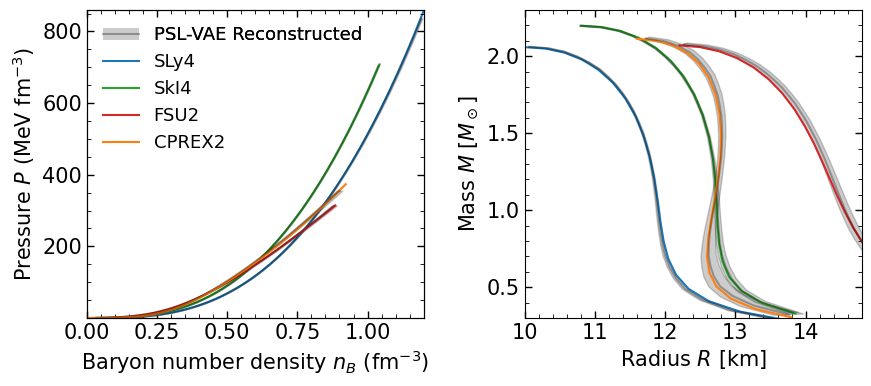

EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_class.py not initialized.
Need to run spectral3_match_gamma1gamma2_trial.py first.
EOS_Spectral3_match EOS CLASS in eos_cla

In [27]:
from matplotlib_rc import *

from Parallel_process import main_parallel_unsave
from eos_class import EOS_interpolation

fig, (ax_eos, ax_mr) = plt.subplots(1, 2, sharey=False,figsize=(10,4))
plt.subplots_adjust(wspace=0.3)

# ax_eos.plot(
#     eos_sly4.eos_array[0], eos_sly4.eos_array[2],
#     lw=2, ls="--", color="b", label=r"SLy4"
# )
#ax_eos.set_yscale('log')
#ax_eos.set_xscale('log')
p_min_plot=0.1
p_max_plot=860
ax_eos.set_xlim(0,1.2)
ax_eos.set_ylim(p_min_plot,p_max_plot)
#ax_mr.set_xlim(10,12.8)
ax_mr.set_xlim(10,14.8)
#ax_mr.set_ylim(0.8,2.3)
ax_mr.set_ylim(0.3,2.3)


eos_sly4_interp = EOS_interpolation(0.16, eos_sly4.eos_array)
pc_vals_sly4 = np.exp(np.linspace(np.log(10), np.log(855), 20))

# MR_sly4 = []
# for pc in pc_vals_sly4:
#     MR_sly4.append(MassRadius(pc, Preset_Pressure_final, Preset_rtol, "MR", eos_sly4_interp))
# MR_sly4 = np.array(MR_sly4).T

# ax_mr.plot(
#     MR_sly4[1]/1000.0, MR_sly4[0],
#     lw=2.2, ls="--", color="b")

def Calculation_MR(eos_data,other_args=[]):
    lnp_array=np.linspace(np.log(eos_data[103]),np.log(eos_data[106]),101)
    cs2_int=interpolate.UnivariateSpline(lnp_array,eos_data[:101], k=2,s=0)
    sol=lsoda_ode_array(f,1e-10,[eos_data[102],np.log(eos_data[101])],np.log(eos_data[103]),lnp_array,cs2_int,method='lsoda')
    eos_array=np.array([np.exp(sol[:,1]),sol[:,0],np.exp(lnp_array)])

    eos_array_complete=np.concatenate((eos_sly4.eos_array[:,np.min(eos_sly4.eos_array<0.9*eos_array[:,[0]],axis=0)],eos_array),axis=1)
    eos=EOS_interpolation(0.16,eos_array_complete)

    MR_data = []
    for pc in np.exp(np.linspace(np.log(5), np.log(eos_data[-1]), 20)):
        MR_data.append(MassRadius(pc, Preset_Pressure_final, Preset_rtol, "MR", eos))
    MR_data = np.array(MR_data).T

    return eos_array_complete,MR_data

for eos_data,encoder,decoder,scaler_X,scaler_y,obs_sigma,curve_color in zip(data_107,encoder_list,decoder_list,scaler_X_list,scaler_y_list,[0.0008,0.0008,0.002,0.002],['tab:blue','tab:green','tab:red','tab:orange']):
    eos_array_complete,MR_data = Calculation_MR(eos_data)

    line_mr, = ax_mr.plot(MR_data[1]/1000.0, MR_data[0], lw=1.5, color=curve_color)
    ax_eos.plot(eos_array_complete[0], eos_array_complete[2], lw=1.5, color=curve_color)

    eos_data_reconstructed_list=[]
    for i in range(1000):
        mu_k_data, mu_u_data, log_var_u_data, z_data = encoder(scaler_X.transform([np.log(eos_data)]), training=False)
        mu_k_data_random=scaler_y.transform(scaler_y.inverse_transform(mu_k_data)*(np.random.normal(0,obs_sigma,2)+1))
        #eos_data_reconstructed = decoder(tf.concat([mu_k_data, mu_u_data], axis=1))
        eos_data_reconstructed = np.exp(decoder(tf.concat([mu_k_data_random, np.array(z_data[:,2:])], axis=1))[0])
        eos_data_reconstructed_list.append(eos_data_reconstructed)
    eos_data_reconstructed=np.array(eos_data_reconstructed_list)
    print(scaler_y.inverse_transform(mu_k_data),mu_u_data,np.exp(log_var_u_data))
    print('n_cc: ',eos_data[-6:-3],'; ',eos_data_reconstructed[:,-6:-3].mean(axis=0),'+-',eos_data_reconstructed[:,-6:-3].std(axis=0))
    print()
    result=(main_parallel_unsave(Calculation_MR,eos_data_reconstructed))
    MR_complete_list=np.array([result_i[1] for result_i in result])

    from scipy.interpolate import interp1d
    beta_max_min=np.infty
    beta_min_max=0
    interp_list=[]
    for MR_i in MR_complete_list:
        beta_max_min=min((MR_i[0]/MR_i[1]*1000).max(),beta_max_min)
        beta_min_max=max((MR_i[0]/MR_i[1]*1000).min(),beta_min_max)
        interp_list.append(interp1d(MR_i[0]/MR_i[1]*1000,MR_i[0]+MR_i[1]/1000))
        #plt.plot(MR_i[1]/1000,MR_i[0])
    beta_plot=np.linspace(beta_min_max,beta_max_min,30)
    interp_MR=[]
    for interp_f in interp_list:
        interp_MR.append(interp_f(beta_plot))
    interp_MR=np.array(interp_MR)
    interp_MR_mean=interp_MR.mean(axis=0)
    interp_MR_std=interp_MR.std(axis=0)
    ax_mr.plot(interp_MR_mean/(beta_plot+1),interp_MR_mean*beta_plot/(beta_plot+1),'k',alpha=0.3)
    
    R=np.concatenate((interp_MR_mean+2*interp_MR_std,(interp_MR_mean-2*interp_MR_std)[::-1]))/(np.concatenate((beta_plot,beta_plot[::-1]))+1)
    M=np.concatenate((interp_MR_mean+2*interp_MR_std,(interp_MR_mean-2*interp_MR_std)[::-1]))/(1+1/np.concatenate((beta_plot,beta_plot[::-1])))
    ax_mr.fill(R,M, color="k", alpha=0.2)

    interp_list=[]
    p_min_max=[p_min_plot,np.infty]
    for result_i in result:
        p_min_max=[max(p_min_max[0],result_i[0][2].min()),min(p_min_max[1],result_i[0][2].max())]
        interp_list.append(interp1d(np.log(result_i[0][2]),np.log(result_i[0][0])))
    lnp_plot=np.linspace(np.log(p_min_max[0]),np.log(p_min_max[1]),100)
    interp_nB=[]
    for interp_f in interp_list:
        interp_nB.append(interp_f(lnp_plot))
    interp_nB=np.array(interp_nB)
    interp_nB_mean=interp_nB.mean(axis=0)
    interp_nB_std =interp_nB.std(axis=0)
    ax_eos.plot(np.exp(interp_nB_mean),np.exp(lnp_plot),'k',alpha=0.3)

    ax_eos.fill_betweenx(np.exp(lnp_plot),np.exp(interp_nB_mean-2*interp_nB_std),np.exp(interp_nB_mean+2*interp_nB_std), color="k", alpha=0.2)

ax_eos.set_xlabel(r"Baryon number density $n_B$ (fm$^{-3}$)",fontsize=15)
ax_eos.set_ylabel(r"Pressure $P$ (MeV fm$^{-3}$)",fontsize=15)
ax_mr.set_xlabel(r"Radius $R$ [km]",fontsize=15)
ax_mr.set_ylabel(r"Mass $M$ [$M_\odot$]",fontsize=15)
ax_mr.set_yticks([0.5,1,1.5,2])
ax_eos.plot([],[],'k',alpha=0.3,label='PSL-VAE Reconstructed')
[ax_eos.plot([],[],label=label, color = color) for  label,color in zip(name_list,['tab:blue','tab:green','tab:red','tab:orange'])]
ax_eos.legend(frameon=False,fontsize=13)
ax_eos_twin=ax_eos.twinx()
ax_eos_twin.fill([],[],'k',alpha=0.2,label='PSL-VAE Reconstructed')
ax_eos_twin.legend(frameon=False,fontsize=13,loc=2)
ax_eos_twin.set_ylim(p_min_plot,p_max_plot)
ax_eos_twin.set_yticklabels('')

plt.savefig('./figures/Reconstruct.pdf',bbox_inches = 'tight',format='pdf')#, dpi=dpi)
